# D4 Blade and rotor design

## Introduction
In the [`D3`](./D3_radial_equilibrium_equation.ipynb) notebook the radial distribution of the flow angles ($\beta_1$, $\beta_2$ and $\beta_m$) along with the $C_L$ coefficient and the chord. Also, a preliminary estimation of the pressure rise was obtained.

In the present session, `D4` we are going to use [NeuralFoil](https://github.com/peterdsharpe/NeuralFoil)(a high speed neural network surrogate model for viscous airfoil aerodynamics) to got still a step forward, and get, for each blade section, the proper camber for the NACA65 profile and the stagger angle, provided the incidence design angle. Basically, we will:

## Learning Objectives
1. **Compute** a NACA 65 profile provided the maximum thickness and a circular camber
2. **Use** NeuralFoil to perform rapid aerodynamics evaluation of costume airfoil profile
3. **Compute** local stagger and blade angles
4. **Export** formatted CSV files for OnShape CAD modelling 

## Previous tasks

Read section `6.3 Blading design` in the thesis by Castegnaro (3 page, about 30 minutes)

## Some simple questions

What is the limitation that Castegnaro comment about the minimum axial velocity on the hub? What is the physical flow phenomenon that we try to avoid?

Answer:

***

Why does Castegnaro suggest taking a distribution of Lieblien Diffusion Factor (DF) instead of a constant one, as we did in `D3`? Why is DF smaller on the tip than in the hub? 

Answer:

***

According to point 8, if we consider american NACA65 profiles instead of British C4, use [airfoiltools](https://airfoiltools.com) to estimate the design incidence angle for the NACA65(1)-212? What are the values of $C_L$ and $C_D$ at this incidence angle?

Answer:

***


## Tasks

In the file [`utils.py`](./resources/utils.py) there are several python functions that can be used to design the blade profile

1. The function `naca65_thickness(x, thickness_ratio)` computes the thickness of the airfoil for an array $x = [0, .., 1.0]$ and given the thickness ratio. It returns an array $y$ of the same size of $x$, with half the thickness for each point (the airfoil is symmetrical).
2. The function `circular_arc_camber(x, design_CL)` estimates a circular arc for an array $x = [0, .., 1.0]$, given an expected design $C_{Ld}$. It uses [thin airfoil theory](https://en.wikipedia.org/wiki/Airfoil#Thin_airfoil_theory) to make an estimation of the camber needed to get the design $C_L$. In brief, it can be shown that, com a maximum camber $h$, located at the middle of the chord, the 0 lift incidence angle is $\alpha_0 = - 2 h$ (in radians), and 
   $$ C_L = 2 \pi \left(\alpha - \alpha_0 \right)  = 2 \pi \left(\alpha + 2 h \right) $$
   On the other hand, it can be also shown that the design incidence angle, $\alpha_d \approx 2 h$ (the angle, relative to the chord, so that the flow is tangential to the camber line in the leading edge). Then
   $$ C_{Ld} = 2 \pi 4 h = 8 \pi h$$
   The angle $g$, computed in the function, is some sort of effective angle of incidence (in radians) for a flat-plate airfoil.
    This function returns the camber line, $y_c$, and its derivative, $\frac{\text{d}y_c}{\text{d}x}$
3. The function `generate_cambered_airfoil(design_CL, thickness_ratio=0.10, n_points=101)` uses the two previous functions to create a cambered NACA65 airfoil with the proper $C_{L,d}$. It returns a dictionary composed by:
   1. `x_coords = [1.0,..,0,..,1.0]`, an array with the $x$ coordinates
   2. `y_coords`, an array for the $y$ coordinates
   3. `camber_line`, an array for the camber coordinates
   4. `thickness_dist`, an array for the thickness distribution
   5. `design_CL`, the $C_{Ld}$ provided as argument
   6. `thickness_ratio`, the maximum thichness-chord ratio, also provided as argument
   7. `name`, a string with the name of the airfoil, with the $C_{Ld}$ and the tickness ratio, like `NACA65-CXXX-HH`, where `XXX` is the design $C_L$ and `HH` is $h$. For example `NACA65-C060-12` is an airfoil with $C_{Ld} = 0.6$, and $h=0.12$.
4. The function `analyze_airfoil_performance(airfoil_data, Re=500000)` use `NeuralFoil` to analyze the airfoil defined by the dictionary of the previous function. It plots, for $-5 \leq \alpha \leq 15$, $C_L$, $C_D$ and $C_L/C_D$. Also returns the design $C_L$ and the design incidence angle, $\alpha_d$ 
5. The function `export_onshape_profile(profile, filename=None)` exports the coordinates of the dictionary defining the airfoil to a CSV file, ready to be imported in `onShape`, as seen in [`C2`](../2_CFD/C2_boundary_layer_and_GCI.ipynb) notebook. If no `filename` is provided, it uses the `name` given in the dictionary.

The computation of the airfoil coordinates is made similarly as pointed out by Lewis

![airfoil coordinates](./images/D4_cambered_profile_Lewis.png)

Let's we use this functions to analyze the medium span-wise section of the TXBR-250 ECOWATT axial fan. 

One of the solution for REE for the mean section this blade could be this:

- Radius = 0.09 m
- beta_1 = 64.34 deg
- beta_2 = 61.22 deg
- beta_m = 62.86 deg
- chord = 33.0 mm
- CL = 0.82

We need a NACA 65 airfoil with a design $C_{Ld} = 0.82$. Let's generate it

In [ ]:
# First, we import the necessary libraries and modules
from resources.utils import *

In [2]:
airfoil = generate_cambered_airfoil(design_CL = 0.82, thickness_ratio = 0.1)


GENERATING AIRFOIL: CL=0.820, thickness=10.0%
Design CL = 0.820
Maximum camber = 3.26% of chord
Leading edge angle = -7.47°
Trailing edge angle = 7.47°
Circular arc radius = 3.848 chord lengths


We can plot the airfoil

(np.float64(-0.05000682256964341),
 np.float64(1.0501432739625116),
 np.float64(-0.03308058815819424),
 np.float64(0.08506008316415764))

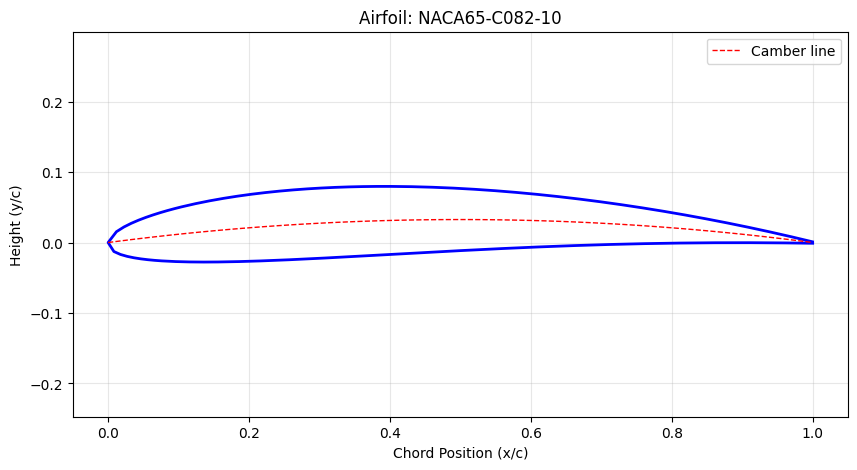

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0,1,len(airfoil['camber_line']))
# Airfoil shape
ax.plot(airfoil['x_coords'], airfoil['y_coords'], 'b-', linewidth=2)
ax.plot(x, airfoil['camber_line'], 'r--', linewidth=1, label='Camber line')
ax.set_xlabel('Chord Position (x/c)')
ax.set_ylabel('Height (y/c)')
ax.set_title(f"Airfoil: {airfoil['name']}")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')


Analyzing NACA65-C082-10 at Re=51800


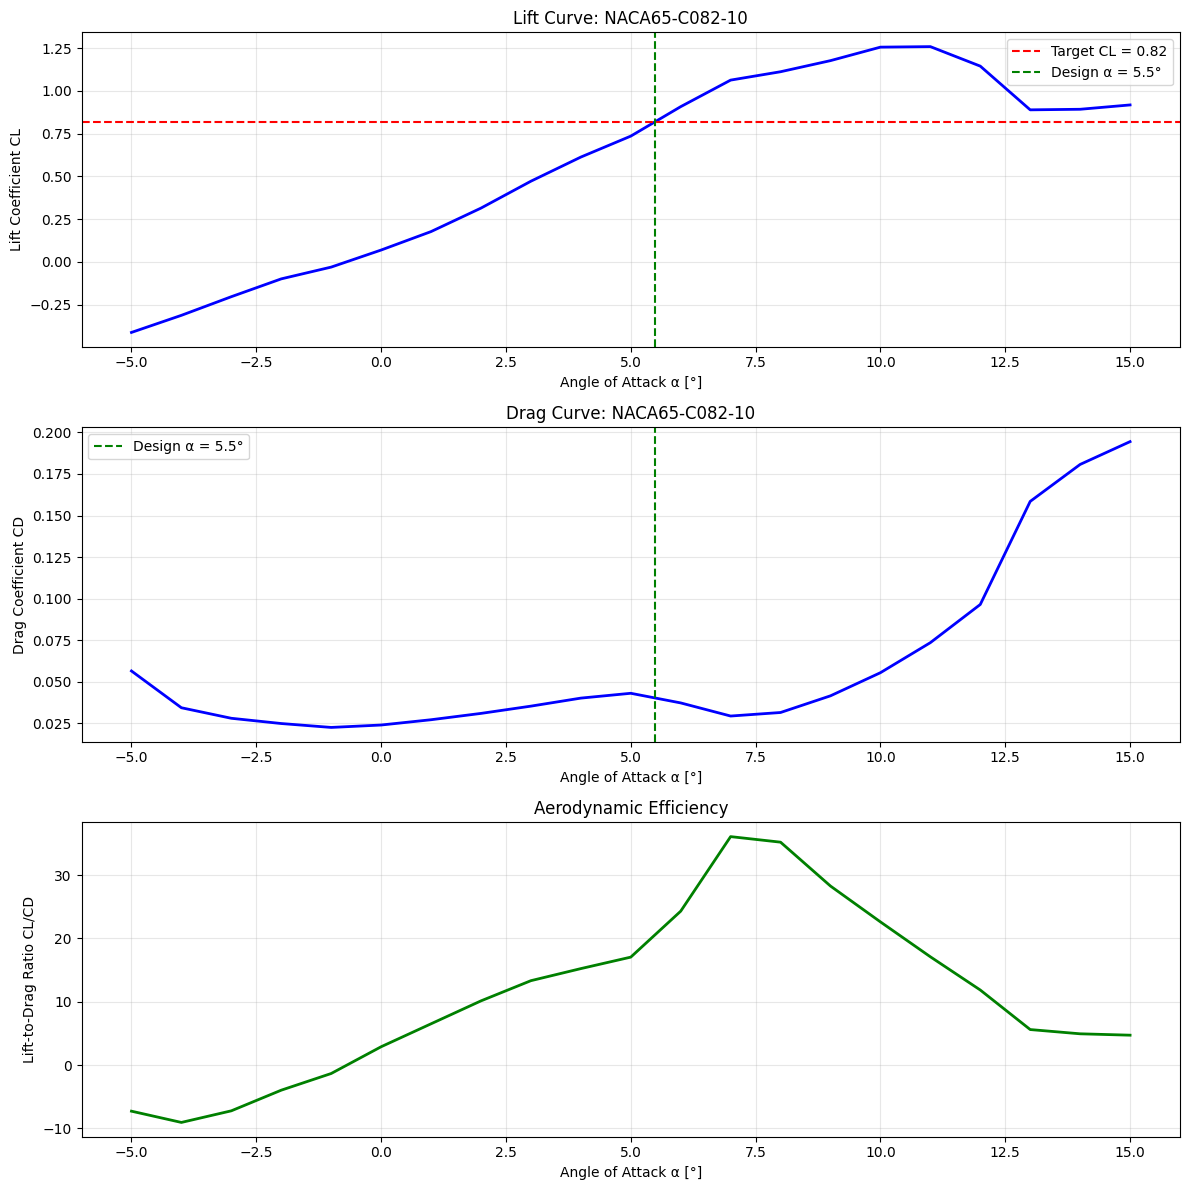

Design angle of attack: 5.49°
CL at design alpha: 0.820


np.float64(5.491288089032932)

In [5]:
analyze_airfoil_performance(airfoil, Re = 51800)

## Your project